<a href="https://colab.research.google.com/github/YLysov0017/PETUXON/blob/master/ML_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install tensorflow

In [2]:
from sklearn.datasets import load_iris
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

#### Установка персонального параметра генератора сл. чисел!!!

In [3]:
from tensorflow.keras.utils import set_random_seed

set_random_seed( 8 )

# для абсолютной повторяемости желательно еще включать детерминизм, особно при работе на GPU,
#но пока можно ограничиться только set_random_seed
#tf.config.experimental.enable_op_determinism()

### Классификация

In [4]:
ds = pd.read_csv('/content/classify08.csv')

x = ds[['Свойство1', 'Свойство2', 'Свойство3', 'Свойство4']]
y = ds['Класс']

xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

nn = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 12, activation = "relu" ),
    Dense( units = 8, activation = "relu" ),
    Dense( units = 6, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] )

nn.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [15]:
hist = nn.fit( xTrain, yTrain, epochs = 40, batch_size = 8, validation_split = 0.1 )

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.7083 - loss: 0.9312 - val_categorical_accuracy: 0.7143 - val_loss: 0.9922
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.7000 - loss: 0.9206 - val_categorical_accuracy: 0.8571 - val_loss: 0.9835
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.7000 - loss: 0.9133 - val_categorical_accuracy: 0.7857 - val_loss: 0.9787
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.7167 - loss: 0.9051 - val_categorical_accuracy: 0.8571 - val_loss: 0.9745
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.7083 - loss: 0.8972 - val_categorical_accuracy: 0.7857 - val_loss: 0.9709
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.7167 - loss: 0.8888 - val_categorical_accuracy: 0.7857 - val_loss: 0.9668
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.7250 - loss: 0.8807 - v

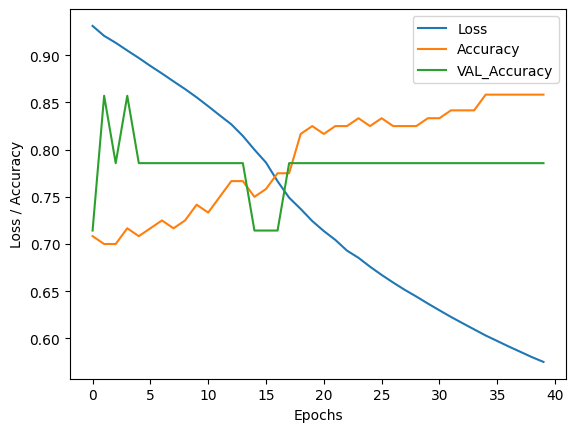

In [16]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

In [7]:
nn.evaluate(xTest, yTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - categorical_accuracy: 0.7273 - loss: 0.9396


[0.9396252036094666, 0.7272727489471436]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - categorical_accuracy: 0.7273 - loss: 0.9396


[0.9396252036094666, 0.7272727489471436]

In [8]:
# "произвольный" пример возьмем из тестового набора
from random import randint


sampleIndex = randint(0, 20)
yPred = nn.predict( xTest.to_numpy()[ sampleIndex ].reshape(1,-1) )

predLabel = np.argmax( yPred )
actLabel = np.where(yTest[sampleIndex] == 1)[0][0]
print(f"Предсказание: {predLabel}, На самом деле: {int(actLabel)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Предсказание: 1, На самом деле: 1


### Работа с переобучением модели

Искусственно создаем переобученную модель и без изменения ее структуры (количество нейронов в слоях) добиваемся снижения эффекта переобучения:
* Слои прореживания Dropout
* L1, L2, L1L2 регуляризация

In [9]:
ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

nnOver = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu" ),
    Dense( units = 128, activation = "relu" ),
    Dense( units = 64, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Намеренно огромное кол-во нейронов

nnOver.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [10]:
hist = nnOver.fit( xTrain, yTrain, epochs = 400, batch_size = 10, validation_split = 0.1 ) # Много эпох

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - categorical_accuracy: 0.5000 - loss: 1.0753 - val_categorical_accuracy: 0.7143 - val_loss: 1.0354
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.6833 - loss: 1.0089 - val_categorical_accuracy: 0.7143 - val_loss: 0.9517
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7167 - loss: 0.9264 - val_categorical_accuracy: 0.7143 - val_loss: 0.8546
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.6917 - loss: 0.8228 - val_categorical_accuracy: 0.7143 - val_loss: 0.7612
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7250 - loss: 0.7256 - val_categorical_accuracy: 0.7143 - val_loss: 0.7049
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7417 - loss: 0.6489 - val_categorical_accuracy: 0.7143 - val_loss: 0.6846
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.7583 - los

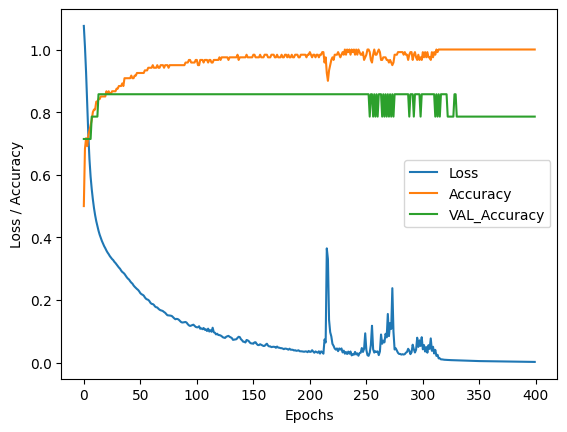

In [11]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

#### Чиним безобразие

In [12]:
from tensorflow.keras.layers import Dropout
nnOverHealed = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = 128, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = 64, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Отключаем случайную половину нейронов и добавляем регуляризацию L2

nnOverHealed.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [13]:
hist = nnOverHealed.fit( xTrain, yTrain, epochs = 50, batch_size = 10, validation_split = 0.1 ) # Уменьшаем эпохи

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - categorical_accuracy: 0.3167 - loss: 3.5115 - val_categorical_accuracy: 0.7143 - val_loss: 3.2654
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.4167 - loss: 3.0762 - val_categorical_accuracy: 0.6429 - val_loss: 2.8756
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.4083 - loss: 2.7361 - val_categorical_accuracy: 0.7143 - val_loss: 2.5594
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.4000 - loss: 2.4623 - val_categorical_accuracy: 0.7857 - val_loss: 2.3021
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.4083 - loss: 2.2326 - val_categorical_accuracy: 0.7143 - val_loss: 2.0809
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.4000 - loss: 2.0569 - val_categorical_accuracy: 0.7857 - val_loss: 1.8964
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.5333 - loss: 1.86

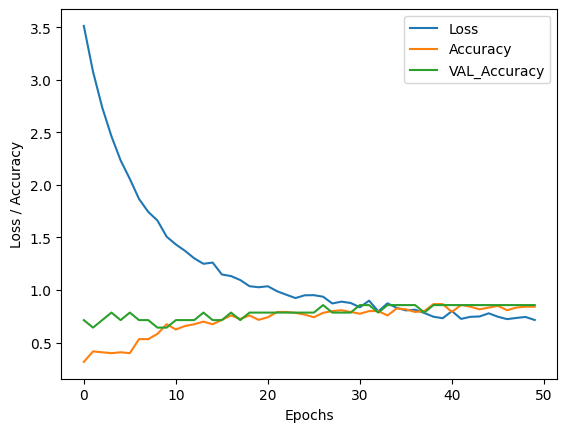

In [14]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

### Регрессия

In [74]:
from sklearn.preprocessing import MinMaxScaler

ds = pd.read_csv('/content/regress08.csv')

x = ds[['V1', 'V2', 'V3', 'V4']]
y = ds['Target']

scaler = MinMaxScaler()
xNorm = scaler.fit_transform(x)

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, y, train_size = 0.67)

nn = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 64, activation = "relu" ),
    Dense( units = 32, activation = "relu" ),
    Dense( units = 16, activation = "relu" ),
    Dense( units = 1 )
] )

nn.compile( loss = "mse",
            optimizer = "adam", metrics = ["mae", "mse"] )

In [80]:
hist = nn.fit( xTrain, yTrain, epochs = 40, batch_size = 32, validation_split = 0.1 )

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 6986.9985 - mae: 67.8508 - mse: 6986.9985 - val_loss: 6981.7905 - val_mae: 68.1535 - val_mse: 6981.7905
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6987.5791 - mae: 67.9084 - mse: 6987.5791 - val_loss: 6971.2563 - val_mae: 68.1182 - val_mse: 6971.2563
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6990.1729 - mae: 68.0058 - mse: 6990.1729 - val_loss: 6959.7773 - val_mae: 68.0759 - val_mse: 6959.7773
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6993.6479 - mae: 68.1104 - mse: 6993.6479 - val_loss: 6949.7515 - val_mae: 68.0339 - val_mse: 6949.7515
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6996.8662 - mae: 68.2001 - mse: 6996.8662 - val_loss: 6941.8242 - val_mae: 67.9971 - val_mse: 6941.8242
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6998.9917 - mae: 68.2676 - mse: 6998.9917 - val_loss: 6935.8110 - val_mae: 67.9676 - val_mse: 6935.8110
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━

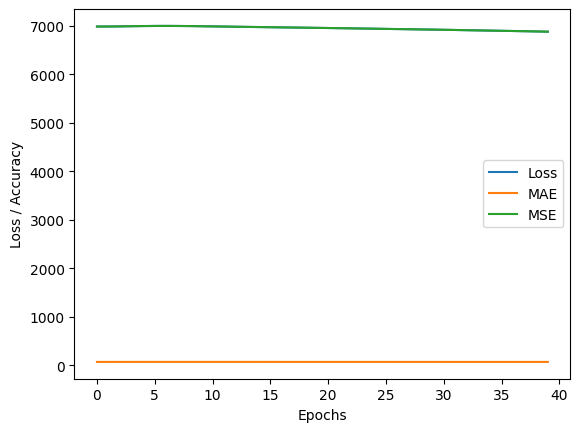

In [81]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["mae"], label = "MAE" )
plt.plot( hist.history["mse"], label = "MSE" )

plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

In [82]:
nn.evaluate(xTest, yTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6545.6748 - mae: 65.0339 - mse: 6545.6748


[6545.6748046875, 65.03390502929688, 6545.6748046875]

In [85]:
# "произвольный" пример возьмем из тестового набора
from random import randint


yPred = nn.predict( xTest )

print(f"Предсказание: {predLabel}, На самом деле: {int(actLabel)}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Предсказание: 0, На самом деле: 260
